# CNN sur MNIST avec PyTorch

Dans ce notebook, je construis un réseau de neurones convolutif pour reconnaître les chiffres manuscrits du dataset MNIST.

MNIST contient des images en niveaux de gris de taille `28 x 28` pixels. Chaque image représente un chiffre entre `0` et `9`.

Le notebook suit une démarche complète :

1. je charge et prépare les données ;
2. je construis un modèle CNN ;
3. je l'entraîne ;
4. j'observe ses résultats ;
5. je regarde ses erreurs ;
6. je sauvegarde le modèle ;
7. je teste ensuite des images personnelles.

L'objectif n'est pas seulement d'obtenir une bonne accuracy. L'objectif est aussi de comprendre ce que fait chaque bloc de code, étape par étape.


## 0. Vérification des dépendances

Avant de commencer, je vérifie que les bibliothèques nécessaires sont disponibles dans le kernel Jupyter.

Les principales bibliothèques utilisées sont :

- `numpy` pour manipuler des tableaux de nombres ;
- `matplotlib` pour afficher des graphiques et des images ;
- `torch` pour construire et entraîner le réseau de neurones ;
- `torchvision` pour télécharger MNIST et appliquer des transformations aux images.

Cette cellule rend le notebook plus simple à lancer avec **Run All**. Si une bibliothèque manque, elle est installée automatiquement dans l'environnement Python utilisé par le notebook.

Je vérifie aussi la version de NumPy, car certaines versions de PyTorch fonctionnent mal avec NumPy 2.x. Si besoin, le notebook force donc `numpy<2`.


In [434]:
# Je vérifie d'abord que les bibliothèques indispensables sont disponibles
# dans le kernel Jupyter qui exécute ce notebook.
import importlib.util
import subprocess
import sys

# Pour chaque bibliothèque, je garde deux noms :
# - le nom utilisé dans un import Python ;
# - le nom utilisé par pip au moment de l'installation.
required_packages = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "torchvision": "torchvision",
}

# Je construis la liste des packages absents.
# Si une bibliothèque est déjà installée, je ne la réinstalle pas.
missing_packages = [
    pip_name
    for import_name, pip_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

# Si quelque chose manque, j'installe directement dans l'environnement
# Python du notebook, pas dans un autre Python de la machine.
if missing_packages:
    print(f"Packages manquants : {missing_packages}")
    print("Installation dans le kernel actif...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
    print("Installation terminée. Si une erreur d'import apparaît ensuite, redémarre le kernel puis relance Run All.")
else:
    print("Toutes les dépendances nécessaires sont déjà installées.")

# Je garde cette sécurité car certaines versions de PyTorch 2.2.x
# fonctionnent mal avec NumPy 2.x.
try:
    import numpy as _np
    numpy_major = int(_np.__version__.split(".")[0])
    if numpy_major >= 2:
        print(f"NumPy {_np.__version__} détecté. Installation de numpy<2 pour compatibilité PyTorch...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy<2"])
        print("NumPy a été corrigé. Redémarre le kernel puis relance Run All.")
except Exception as error:
    print(f"Vérification NumPy ignorée : {error}")


Toutes les dépendances nécessaires sont déjà installées.


## 1. Imports

Ici, j'importe les outils dont j'aurai besoin dans tout le notebook.

Je fixe aussi des graines aléatoires avec `torch.manual_seed(42)` et `np.random.seed(42)`. Cela permet d'avoir des résultats plus stables d'une exécution à l'autre.

Ensuite, je choisis automatiquement le meilleur matériel disponible :

- `mps` si le notebook tourne sur un Mac Apple Silicon ;
- `cuda` si une carte graphique NVIDIA est disponible ;
- `cpu` sinon.

Ce choix est important, car l'entraînement d'un réseau de neurones peut être beaucoup plus rapide sur GPU.


In [435]:
# J'importe les bibliothèques numériques et graphiques.
import numpy as np
import matplotlib.pyplot as plt

# J'importe PyTorch : c'est la bibliothèque qui va construire,
# entraîner et évaluer le réseau de neurones.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

# torchvision me donne accès au dataset MNIST et aux transformations d'images.
from torchvision import datasets, transforms

# Je fixe les graines aléatoires pour rendre les résultats plus reproductibles.
# Sans cela, le découpage train/validation et l'initialisation du modèle
# peuvent légèrement changer à chaque exécution.
torch.manual_seed(42)
np.random.seed(42)

# Je choisis automatiquement le meilleur matériel disponible :
# - mps : accélération Apple Silicon ;
# - cuda : carte graphique NVIDIA ;
# - cpu : processeur classique si rien d'autre n'est disponible.
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device utilisé : {device}")


Device utilise : mps


## 2. Paramètres à ajuster

Cette cellule regroupe les paramètres importants du projet. C'est volontaire : cela permet de tester plusieurs configurations sans modifier tout le notebook.

Les principaux paramètres sont :

- `EPOCHS` : nombre de passages complets sur le train set ;
- `BATCH_SIZE` : nombre d'images traitées avant une mise à jour des poids ;
- `LEARNING_RATE` : taille du pas d'apprentissage ;
- `DROPOUT_RATE` : proportion de neurones désactivés pendant l'entraînement ;
- `USE_AUGMENTATION` : active ou non les petites transformations sur les images de train ;
- `AUGMENTATION_DEGREES` : angle maximal de rotation pendant l'augmentation ;
- `MODEL_VERSION` : choix entre le CNN à 2 convolutions et celui à 3 convolutions.

Ces paramètres permettent de faire évoluer le modèle progressivement et d'observer l'impact de chaque choix.


In [436]:
# Je regroupe ici les paramètres principaux pour pouvoir expérimenter
# sans modifier toutes les cellules du notebook.
EPOCHS = 12                 # Nombre de passages complets sur les images d'entraînement.
BATCH_SIZE = 64             # Nombre d'images traitées avant une mise à jour des poids.
LEARNING_RATE = 0.0005      # Taille des pas faits par l'optimiseur pendant l'apprentissage.
DROPOUT_RATE = 0.25         # Proportion de neurones désactivés au hasard pendant l'entraînement.
USE_AUGMENTATION = True     # J'ajoute de petites variations aux images de train si cette valeur vaut True.
AUGMENTATION_DEGREES = 0    # 0 = aucune rotation pendant l'augmentation du train.
MODEL_VERSION = "cnn_3conv"  # Choix possibles : "cnn_2conv" ou "cnn_3conv".

# Je garde 10 % du train set pour mesurer la progression sur des images
# que le modèle ne voit pas pendant l'apprentissage.
VALIDATION_RATIO = 0.1
NUM_CLASSES = 10            # MNIST contient les chiffres de 0 à 9, donc 10 classes.


## 3. Chargement du dataset MNIST

Je charge ici le dataset MNIST avec `torchvision.datasets.MNIST`.

Avant d'être envoyées au modèle, les images sont transformées. La transformation de base contient deux étapes :

```python
transforms.ToTensor()
transforms.Normalize((0.1307,), (0.3081,))
```

`ToTensor()` transforme l'image en tenseur PyTorch. Une image MNIST devient alors un tenseur de forme :

```text
1 x 28 x 28
```

Le `1` correspond au canal unique de l'image, car MNIST est en niveaux de gris.

`Normalize` centre et réduit les valeurs avec la moyenne et l'écart-type classiques du dataset MNIST. Cela aide le modèle à apprendre sur une échelle plus stable.

Je définis aussi une version augmentée du train set. L'augmentation applique de petites variations : déplacement, changement d'échelle, éventuellement rotation. Elle est utilisée uniquement sur le train set, jamais sur la validation ni sur le test, pour garder une évaluation stable.

Enfin, je découpe le train set en deux parties :

- une partie pour entraîner le modèle ;
- une partie pour valider ses performances pendant les essais.


In [437]:
# Je définis la transformation de base appliquée aux images MNIST.
# ToTensor transforme l'image PIL en tenseur PyTorch de forme 1 x 28 x 28.
# Normalize centre et réduit les valeurs avec les statistiques classiques de MNIST.
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Cette transformation est utilisée seulement pour l'entraînement.
# Je modifie légèrement les images pour apprendre au modèle à reconnaître
# un chiffre même s'il est un peu déplacé ou changé d'échelle.
augmented_transform = transforms.Compose([
    transforms.RandomAffine(degrees=AUGMENTATION_DEGREES, translate=(0.08, 0.08), scale=(0.98, 1.10)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Je choisis la version augmentée ou non selon le paramètre USE_AUGMENTATION.
train_transform = augmented_transform if USE_AUGMENTATION else basic_transform

# Important : je réserve l'augmentation au train.
# Validation et test doivent rester stables pour mesurer le modèle
# sur les mêmes images à chaque évaluation.
mnist_train_full_augmented = datasets.MNIST(root="data", train=True, download=True, transform=train_transform)
mnist_train_full_basic = datasets.MNIST(root="data", train=True, download=True, transform=basic_transform)
mnist_test = datasets.MNIST(root="data", train=False, download=True, transform=basic_transform)

# Je calcule la taille de la validation, puis celle du train.
validation_size = int(len(mnist_train_full_basic) * VALIDATION_RATIO)
train_size = len(mnist_train_full_basic) - validation_size

# Je mélange les indices avec une graine fixe pour obtenir toujours
# le même découpage train/validation.
indices = torch.randperm(len(mnist_train_full_basic), generator=torch.Generator().manual_seed(42)).tolist()
train_indices = indices[:train_size]
validation_indices = indices[train_size:]

# Je crée deux sous-ensembles :
# - train avec augmentation possible ;
# - validation sans augmentation, pour une mesure fiable.
mnist_train = Subset(mnist_train_full_augmented, train_indices)
mnist_validation = Subset(mnist_train_full_basic, validation_indices)

print(f"Images train      : {len(mnist_train)}")
print(f"Images validation : {len(mnist_validation)}")
print(f"Images test       : {len(mnist_test)}")
print(f"Augmentation train uniquement : {USE_AUGMENTATION}")


Images train      : 54000
Images validation : 6000
Images test       : 10000
Augmentation train uniquement : True


## 4. DataLoaders

Un `DataLoader` sert à découper le dataset en petits paquets appelés batches.

Avec `BATCH_SIZE = 64`, le modèle traite 64 images à la fois avant de mettre à jour ses poids.

Pour le train set, j'utilise `shuffle=True`. Cela mélange les images à chaque epoch, afin que le modèle ne voie pas toujours les chiffres dans le même ordre.

La validation et le test utilisent `shuffle=False`, car je veux garder un ordre stable pour l'évaluation.

À la fin de la cellule, j'affiche les dimensions d'un batch pour vérifier que les données ont bien la forme attendue :

```text
batch_size x 1 x 28 x 28
```


In [438]:
# Un DataLoader découpe le dataset en petits paquets appelés batches.
# C'est plus efficace que d'envoyer les 60 000 images d'un coup au modèle.
train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(mnist_validation, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False)

# Je regarde un batch pour vérifier les dimensions.
# Pour MNIST, un batch d'images a la forme : batch_size x 1 x 28 x 28.
# Le 1 correspond au canal unique des images en niveaux de gris.
images, labels = next(iter(train_loader))
print(f"Shape d'un batch d'images : {images.shape}")
print(f"Shape d'un batch de labels : {labels.shape}")
print(f"Shape d'une image : {images[0].shape}")


Shape d'un batch d'images : torch.Size([64, 1, 28, 28])
Shape d'un batch de labels : torch.Size([64])
Shape d'une image : torch.Size([1, 28, 28])


## 5. Répartition des classes

Avant d'entraîner un modèle, je vérifie la répartition des classes.

L'idée est de compter combien d'images correspondent à chaque chiffre de `0` à `9`.

Cette étape est importante : si un chiffre était beaucoup moins représenté que les autres, le modèle pourrait moins bien l'apprendre. Ici, MNIST est globalement équilibré, mais le graphique permet de le vérifier visuellement.


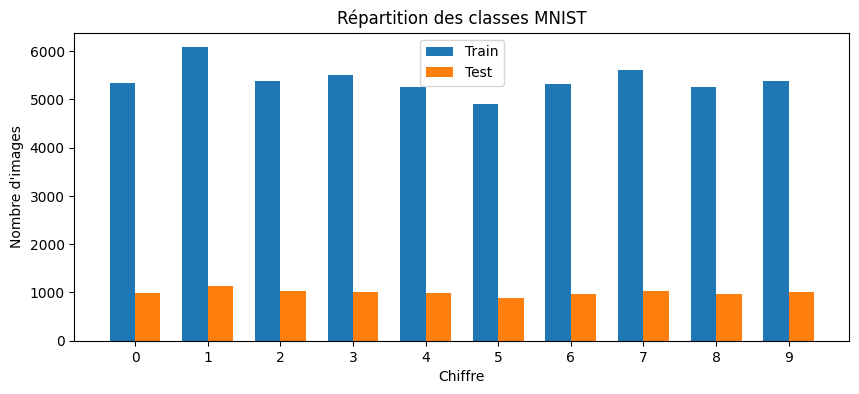

In [439]:
def count_classes(dataset, num_classes=10):
    """Je compte combien d'images appartiennent à chaque chiffre."""
    counts = np.zeros(num_classes, dtype=int)
    for _, label in dataset:
        counts[label] += 1
    return counts


# Je compare la répartition des chiffres dans le train et dans le test.
# Cela permet de vérifier qu'une classe n'est pas beaucoup plus représentée
# qu'une autre.
train_counts = count_classes(mnist_train)
test_counts = count_classes(mnist_test)

x = np.arange(NUM_CLASSES)
width = 0.35

plt.figure(figsize=(10, 4))
plt.bar(x - width / 2, train_counts, width, label="Train")
plt.bar(x + width / 2, test_counts, width, label="Test")
plt.xticks(x)
plt.xlabel("Chiffre")
plt.ylabel("Nombre d'images")
plt.title("Répartition des classes MNIST")
plt.legend()
plt.show()


## 6. Visualisation des 50 premières images

Avant de faire confiance à un modèle, je regarde toujours les données.

Cette cellule affiche quelques images MNIST avec leur label. Cela permet de comprendre concrètement ce que le modèle va recevoir : des chiffres manuscrits, en noir et blanc, parfois bien écrits, parfois ambigus.

Comme les images ont été normalisées, j'utilise `denormalize_mnist` pour les remettre dans une échelle affichable par `matplotlib`.


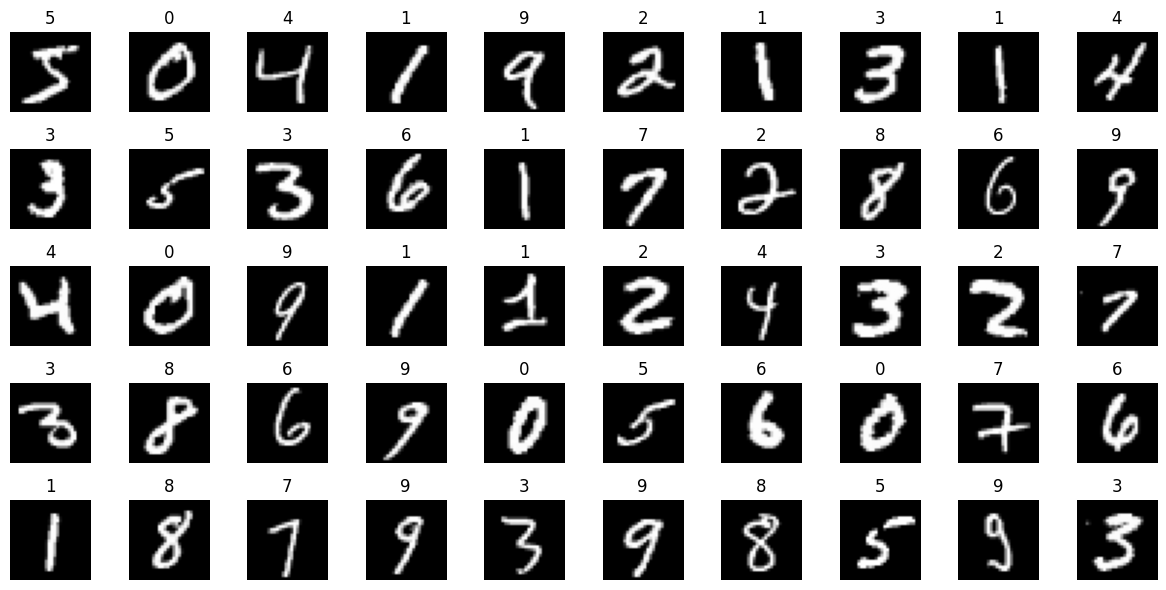

In [440]:
def denormalize_mnist(image):
    """Je remets une image normalisée dans une échelle affichable."""
    return image * 0.3081 + 0.1307


# Je visualise quelques images pour comprendre concrètement ce que voit le modèle.
# Ici, j'utilise la version sans augmentation pour afficher les chiffres originaux.
plt.figure(figsize=(12, 6))
for i in range(50):
    image, label = mnist_train_full_basic[i]
    image = denormalize_mnist(image).squeeze(0).numpy()

    plt.subplot(5, 10, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(str(label))
    plt.axis("off")

plt.tight_layout()
plt.show()


## 7. Modèle CNN

Je définis ici le réseau de neurones convolutif.

Un CNN est bien adapté aux images, car il apprend des filtres capables de détecter des motifs locaux : traits, bords, courbes, coins ou formes simples.

Le modèle est séparé en deux parties :

- `features` : extrait les caractéristiques visuelles de l'image ;
- `classifier` : transforme ces caractéristiques en prédiction finale.

Deux architectures sont disponibles avec `MODEL_VERSION`.

Architecture `cnn_2conv` :

```text
Entrée : 1 x 28 x 28
-> Conv 1 : 16 x 28 x 28
-> ReLU
-> MaxPool : 16 x 14 x 14
-> Conv 2 : 32 x 14 x 14
-> ReLU
-> MaxPool : 32 x 7 x 7
-> Flatten : 32 * 7 * 7
-> Linear : 128
-> ReLU
-> Dropout
-> Linear : 10
```

Architecture `cnn_3conv` :

```text
Entrée : 1 x 28 x 28
-> Conv 1 : 16 x 28 x 28
-> ReLU
-> MaxPool : 16 x 14 x 14
-> Conv 2 : 32 x 14 x 14
-> ReLU
-> MaxPool : 32 x 7 x 7
-> Conv 3 : 64 x 7 x 7
-> ReLU
-> Flatten : 64 * 7 * 7
-> Linear : 128
-> ReLU
-> Dropout
-> Linear : 10
```

Quelques notions importantes :

- `Conv2d` apprend des filtres sur l'image ;
- `ReLU` ajoute de la non-linéarité ;
- `MaxPool2d` réduit la taille de l'image en gardant les signaux forts ;
- `Flatten` transforme les cartes d'activation en vecteur ;
- `Linear` produit les scores de classification ;
- `Dropout` limite le surapprentissage.

La dernière couche renvoie 10 scores : un score pour chaque chiffre de `0` à `9`.


In [441]:
class MNISTCNN2Conv(nn.Module):
    """Je définis un CNN simple : 2 convolutions + 2 max-pooling."""

    def __init__(self, dropout_rate=0.25):
        super().__init__()

        # La partie features extrait des informations visuelles de l'image.
        # Une convolution apprend des filtres capables de détecter des motifs
        # locaux : traits, bords, courbes, coins, etc.
        self.features = nn.Sequential(
            # Entrée : 1 x 28 x 28.
            # Je produis 16 cartes de caractéristiques de taille 28 x 28.
            # padding=1 garde la même largeur et la même hauteur après une convolution 3 x 3.
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),  # Je garde les signaux positifs et j'ajoute de la non-linéarité.
            nn.MaxPool2d(kernel_size=2, stride=2),  # Je réduis 28 x 28 en 14 x 14.

            # Je repars des 16 cartes précédentes et j'en apprends 32 nouvelles.
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Je réduis 14 x 14 en 7 x 7.
        )

        # La partie classifier transforme les caractéristiques en décision finale.
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # Je transforme 32 x 7 x 7 en un vecteur de 1568 valeurs.
            nn.Linear(32 * 7 * 7, 128),   # Je combine ces valeurs dans 128 neurones.
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),   # Pendant le train, je coupe au hasard une partie des neurones pour limiter le par cœur.
            nn.Linear(128, 10),           # Je produis 10 scores : un score pour chaque chiffre de 0 à 9.
        )

    def forward(self, x):
        # Le forward décrit le trajet d'une image dans le modèle.
        x = self.features(x)
        x = self.classifier(x)
        return x


class MNISTCNN3Conv(nn.Module):
    """Je définis une variante plus expressive : 3 convolutions, mais seulement 2 max-pooling."""

    def __init__(self, dropout_rate=0.25):
        super().__init__()

        self.features = nn.Sequential(
            # Entrée : 1 x 28 x 28, car MNIST est en niveaux de gris.
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # Je passe de 28 x 28 à 14 x 14.

            # Je détecte des motifs plus riches à partir des 16 premières cartes.
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # Je passe de 14 x 14 à 7 x 7.

            # Cette troisième convolution ajoute de la capacité au modèle.
            # Je ne remets pas de max-pooling ici pour ne pas réduire l'image en dessous de 7 x 7.
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),                                  # La taille reste 7 x 7.
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                 # Je transforme 64 x 7 x 7 en un vecteur de 3136 valeurs.
            nn.Linear(64 * 7 * 7, 128),   # Je résume ces informations dans 128 neurones.
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),   # Je force le modèle à ne pas dépendre toujours des mêmes neurones.
            nn.Linear(128, 10),           # Je produis les 10 scores finaux.
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Je choisis l'architecture à utiliser grâce au paramètre MODEL_VERSION.
if MODEL_VERSION == "cnn_2conv":
    model = MNISTCNN2Conv(dropout_rate=DROPOUT_RATE).to(device)
elif MODEL_VERSION == "cnn_3conv":
    model = MNISTCNN3Conv(dropout_rate=DROPOUT_RATE).to(device)
else:
    raise ValueError("MODEL_VERSION doit valoir 'cnn_2conv' ou 'cnn_3conv'.")

print(f"Modèle utilisé : {MODEL_VERSION}")

# Je crée un faux batch de 4 images pour vérifier les dimensions internes
# sans attendre l'entraînement.
dummy_batch = torch.randn(4, 1, 28, 28).to(device)
with torch.no_grad():
    features_shape = model.features(dummy_batch).shape
    output_shape = model(dummy_batch).shape

print(f"Sortie convolutions : {features_shape}")
print(f"Sortie modèle       : {output_shape}")

model


Modèle utilisé : cnn_3conv
Sortie convolutions : torch.Size([4, 64, 7, 7])
Sortie modèle       : torch.Size([4, 10])


MNISTCNN3Conv(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

## 8. Loss et optimizer

Pour entraîner le modèle, il faut deux éléments : une fonction de perte et un optimiseur.

La fonction de perte utilisée est `CrossEntropyLoss`. Elle est adaptée à une classification multi-classes comme MNIST. Le modèle produit 10 scores, et la loss mesure l'écart entre ces scores et la vraie classe.

L'optimiseur utilisé est `Adam`. Son rôle est de modifier les poids du modèle pour faire diminuer la loss.

Le `learning rate` défini plus haut contrôle la taille des pas faits par l'optimiseur.


In [442]:
# La loss mesure l'erreur entre les scores du modèle et la bonne classe.
# CrossEntropyLoss est adaptée à une classification multi-classes comme MNIST.
criterion = nn.CrossEntropyLoss()

# L'optimizer Adam modifie les poids du modèle pour faire baisser la loss.
# lr correspond au learning rate défini plus haut.
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


## 9. Fonctions train / evaluate

Je définis ici deux fonctions centrales.

`train_one_epoch` entraîne le modèle pendant une epoch. Une epoch correspond à un passage complet sur toutes les images d'entraînement.

La logique est la suivante :

```python
model.train()
optimizer.zero_grad()
outputs = model(images)
loss = criterion(outputs, labels)
loss.backward()
optimizer.step()
```

Étape par étape :

1. je passe le modèle en mode entraînement ;
2. je remets les gradients à zéro ;
3. je fais passer les images dans le modèle ;
4. je calcule l'erreur avec la loss ;
5. je calcule les gradients avec `backward()` ;
6. je mets à jour les poids avec `optimizer.step()`.

`evaluate` mesure les performances sans modifier les poids du modèle.

Elle utilise :

```python
model.eval()
with torch.no_grad():
```

`model.eval()` désactive certains comportements d'entraînement, comme le dropout. `torch.no_grad()` évite de calculer les gradients et économise de la mémoire.


In [443]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """J'entraîne le modèle pendant un passage complet sur le train set."""
    model.train()  # J'active le mode entraînement : le dropout est actif.
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # J'envoie les données sur le même device que le modèle.
        images = images.to(device)
        labels = labels.to(device)

        # 1. Je remets les gradients à zéro avant de traiter le batch.
        optimizer.zero_grad()

        # 2. Je fais passer les images dans le modèle : c'est le forward pass.
        outputs = model(images)

        # 3. Je compare les sorties du modèle aux vraies réponses.
        loss = criterion(outputs, labels)

        # 4. Je calcule les gradients : PyTorch mesure comment chaque poids
        # doit changer pour réduire l'erreur.
        loss.backward()

        # 5. Je mets à jour les poids du modèle.
        optimizer.step()

        # Je cumule la loss et le nombre de bonnes réponses pour suivre l'epoch.
        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """J'évalue le modèle sans modifier ses poids."""
    model.eval()  # J'active le mode évaluation : le dropout est désactivé.
    total_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    # no_grad économise de la mémoire car je n'ai pas besoin de gradients
    # pendant la validation ou le test.
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            predictions = outputs.argmax(dim=1)

            total_loss += loss.item() * images.size(0)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Je rapatrie les résultats sur CPU pour pouvoir les analyser avec NumPy.
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_predictions), np.array(all_labels)


## 10. Entraînement

Je lance maintenant l'entraînement du modèle.

À chaque epoch, le notebook calcule :

- la loss sur le train set ;
- l'accuracy sur le train set ;
- la loss sur la validation ;
- l'accuracy sur la validation.

Ces valeurs sont stockées dans `history` pour pouvoir tracer des courbes ensuite.

Le nombre exact d'epochs dépend du paramètre `EPOCHS` défini au début du notebook.


In [453]:
# Je garde l'historique pour tracer ensuite les courbes d'apprentissage.
history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
}

# Une epoch correspond à un passage complet sur toutes les images de train.
for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy, _, _ = evaluate(model, validation_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(val_loss)
    history["validation_accuracy"].append(val_accuracy)

    # J'affiche les métriques à chaque epoch pour voir si le modèle progresse.
    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"| train loss: {train_loss:.4f} "
        f"| train acc: {train_accuracy:.4f} "
        f"| val loss: {val_loss:.4f} "
        f"| val acc: {val_accuracy:.4f}"
    )


Epoch 1/12 | train loss: 0.0256 | train acc: 0.9919 | val loss: 0.0221 | val acc: 0.9928
Epoch 2/12 | train loss: 0.0257 | train acc: 0.9915 | val loss: 0.0306 | val acc: 0.9900
Epoch 3/12 | train loss: 0.0248 | train acc: 0.9922 | val loss: 0.0218 | val acc: 0.9943
Epoch 4/12 | train loss: 0.0238 | train acc: 0.9924 | val loss: 0.0183 | val acc: 0.9940
Epoch 5/12 | train loss: 0.0221 | train acc: 0.9926 | val loss: 0.0235 | val acc: 0.9922
Epoch 6/12 | train loss: 0.0211 | train acc: 0.9934 | val loss: 0.0253 | val acc: 0.9930
Epoch 7/12 | train loss: 0.0215 | train acc: 0.9931 | val loss: 0.0219 | val acc: 0.9932
Epoch 8/12 | train loss: 0.0199 | train acc: 0.9939 | val loss: 0.0244 | val acc: 0.9935
Epoch 9/12 | train loss: 0.0188 | train acc: 0.9939 | val loss: 0.0236 | val acc: 0.9932
Epoch 10/12 | train loss: 0.0186 | train acc: 0.9938 | val loss: 0.0233 | val acc: 0.9932
Epoch 11/12 | train loss: 0.0179 | train acc: 0.9943 | val loss: 0.0283 | val acc: 0.9918
Epoch 12/12 | train

## 11. Visualisation des epochs

Les courbes permettent de lire l'apprentissage plus facilement que les valeurs imprimées ligne par ligne.

La courbe de loss doit idéalement descendre : cela signifie que le modèle fait moins d'erreurs.

La courbe d'accuracy doit idéalement monter : cela signifie que le modèle prédit mieux.

Il faut surtout comparer train et validation :

- si train et validation progressent ensemble, le modèle apprend bien ;
- si le train progresse mais que la validation stagne ou baisse, il peut y avoir surapprentissage ;
- si tout stagne, le modèle, le learning rate ou les paramètres peuvent être à revoir.


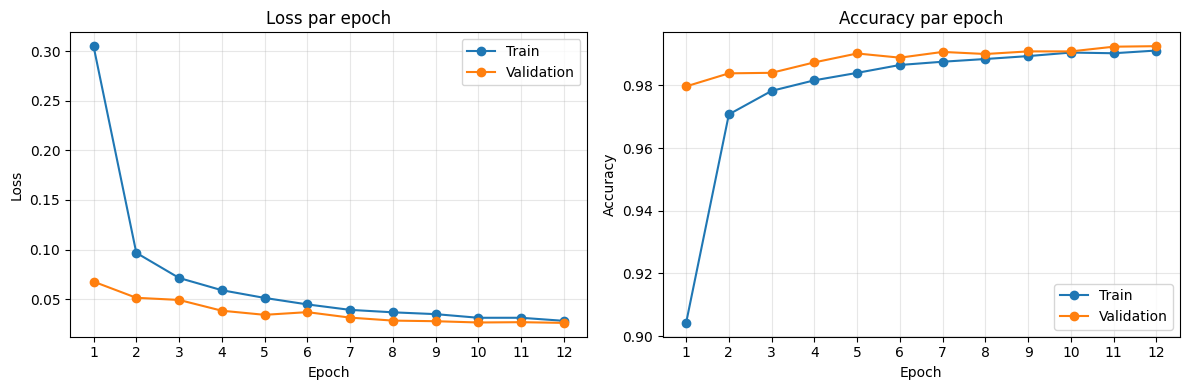

In [445]:
# Je trace les courbes pour lire l'apprentissage plus facilement
# qu'avec les valeurs imprimées ligne par ligne.
epochs_range = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

# La loss doit idéalement diminuer au fil des epochs.
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train")
plt.plot(epochs_range, history["validation_loss"], marker="o", label="Validation")
plt.title("Loss par epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(alpha=0.3)

# L'accuracy doit idéalement augmenter au fil des epochs.
# Si le train monte mais pas la validation, je peux soupçonner du surapprentissage.
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_accuracy"], marker="o", label="Train")
plt.plot(epochs_range, history["validation_accuracy"], marker="o", label="Validation")
plt.title("Accuracy par epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_range)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 12. Évaluation sur le test set

Le test set sert à mesurer la performance finale du modèle.

Il ne doit pas servir à choisir les paramètres pendant les essais. Pour les réglages, j'utilise plutôt la validation.

Ici, je récupère :

- la loss finale sur le test ;
- l'accuracy finale ;
- toutes les prédictions ;
- tous les vrais labels.

Les prédictions et labels seront ensuite utilisés pour construire la matrice de confusion.


In [446]:
# Le test set est utilisé à la fin pour obtenir une estimation finale
# sur des images que le modèle n'a pas vues pendant l'entraînement.
test_loss, test_accuracy, test_predictions, test_labels = evaluate(model, test_loader, criterion, device)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")


Test loss     : 0.0183
Test accuracy : 0.9941


## 13. Matrice de confusion

L'accuracy globale donne une moyenne, mais elle ne dit pas quels chiffres sont bien ou mal reconnus.

La matrice de confusion permet d'aller plus loin.

Dans cette matrice :

- les lignes représentent les vraies classes ;
- les colonnes représentent les prédictions du modèle ;
- la diagonale correspond aux bonnes réponses.

Exemple : ligne `9`, colonne `8` signifie que des vrais `9` ont été prédits comme des `8`.

Je calcule aussi l'accuracy par classe :

```python
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
```

C'est une étape importante du projet, car une très bonne accuracy globale peut cacher un chiffre moins bien détecté que les autres.


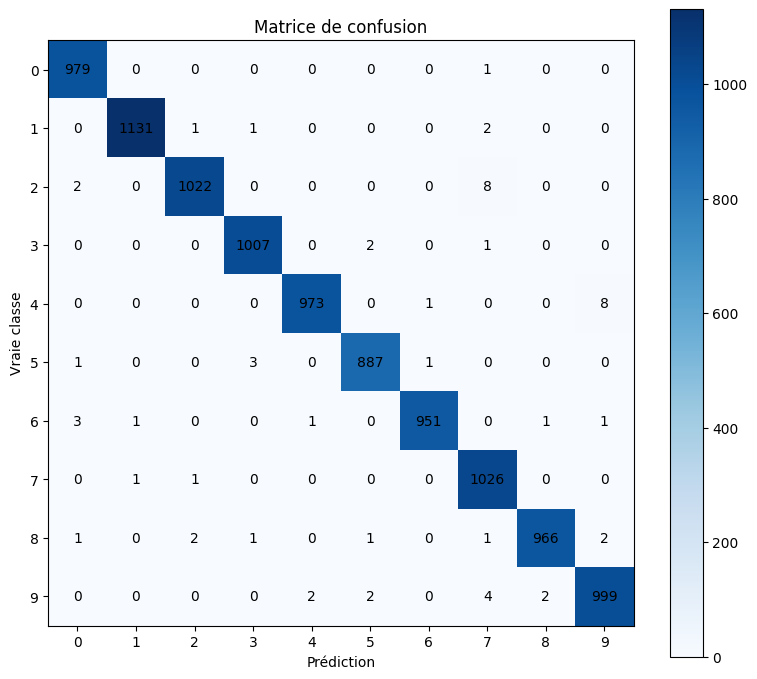

Chiffre 0 : accuracy 0.9990
Chiffre 1 : accuracy 0.9965
Chiffre 2 : accuracy 0.9903
Chiffre 3 : accuracy 0.9970
Chiffre 4 : accuracy 0.9908
Chiffre 5 : accuracy 0.9944
Chiffre 6 : accuracy 0.9927
Chiffre 7 : accuracy 0.9981
Chiffre 8 : accuracy 0.9918
Chiffre 9 : accuracy 0.9901

Chiffre le mieux détecté : 0
Chiffre le moins bien détecté : 9


In [447]:
def confusion_matrix_numpy(y_true, y_pred, num_classes=10):
    """Je construis une matrice qui croise vraies classes et prédictions."""
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        matrix[true_label, pred_label] += 1
    return matrix


cm = confusion_matrix_numpy(test_labels, test_predictions, NUM_CLASSES)

# Dans cette matrice, les bonnes prédictions sont sur la diagonale.
# Exemple : ligne 7, colonne 7 = nombre de vrais 7 prédits comme 7.
plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

# Je calcule ensuite l'accuracy séparément pour chaque chiffre.
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
for digit, acc in enumerate(per_class_accuracy):
    print(f"Chiffre {digit} : accuracy {acc:.4f}")

print(f"\nChiffre le mieux détecté : {per_class_accuracy.argmax()}")
print(f"Chiffre le moins bien détecté : {per_class_accuracy.argmin()}")


## 14. Quelques prédictions

Cette cellule affiche quelques prédictions du modèle sur le test set.

Le titre indique :

- le vrai chiffre ;
- le chiffre prédit ;
- une couleur verte si la prédiction est correcte ;
- une couleur rouge si elle est incorrecte.

C'est une manière simple de vérifier visuellement si le modèle se comporte comme prévu.


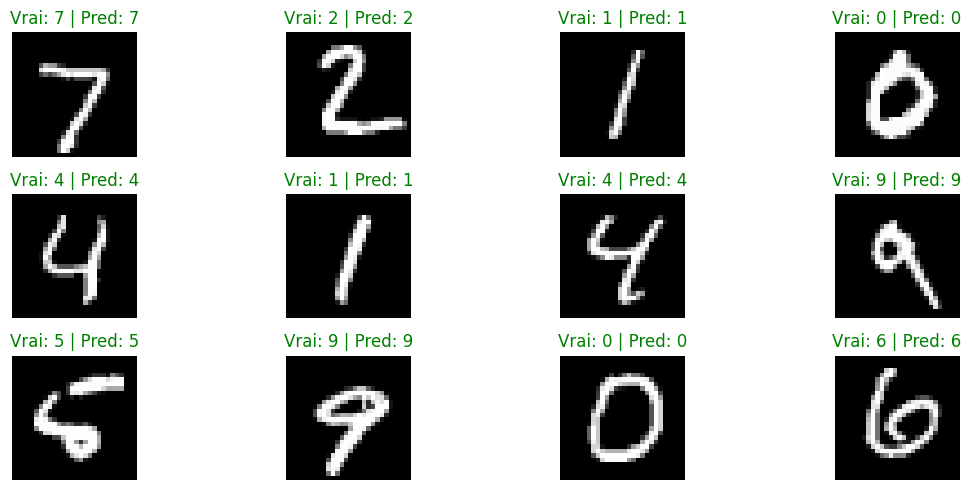

In [448]:
def show_predictions(model, loader, device, n_images=12):
    """J'affiche quelques prédictions pour contrôler visuellement le modèle."""
    model.eval()
    images, labels = next(iter(loader))
    images_device = images.to(device)

    with torch.no_grad():
        outputs = model(images_device)
        predictions = outputs.argmax(dim=1).cpu()

    n_images = min(n_images, len(images))
    plt.figure(figsize=(12, 5))

    for i in range(n_images):
        image = denormalize_mnist(images[i]).squeeze(0).numpy()
        true_label = labels[i].item()
        pred_label = predictions[i].item()
        color = "green" if true_label == pred_label else "red"

        plt.subplot(3, 4, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Vrai: {true_label} | Pred: {pred_label}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(model, test_loader, device, n_images=12)


## 15. Diagnostic : images mal classées

Cette cellule affiche uniquement les erreurs du modèle.

C'est souvent la partie la plus instructive : une erreur peut être due à un chiffre ambigu, mal écrit, très incliné ou proche d'un autre chiffre.

Regarder les erreurs permet de comprendre ce que l'accuracy ne dit pas. C'est aussi ce qui peut guider les améliorations : plus d'epochs, augmentation de données, dropout, ou architecture plus expressive.


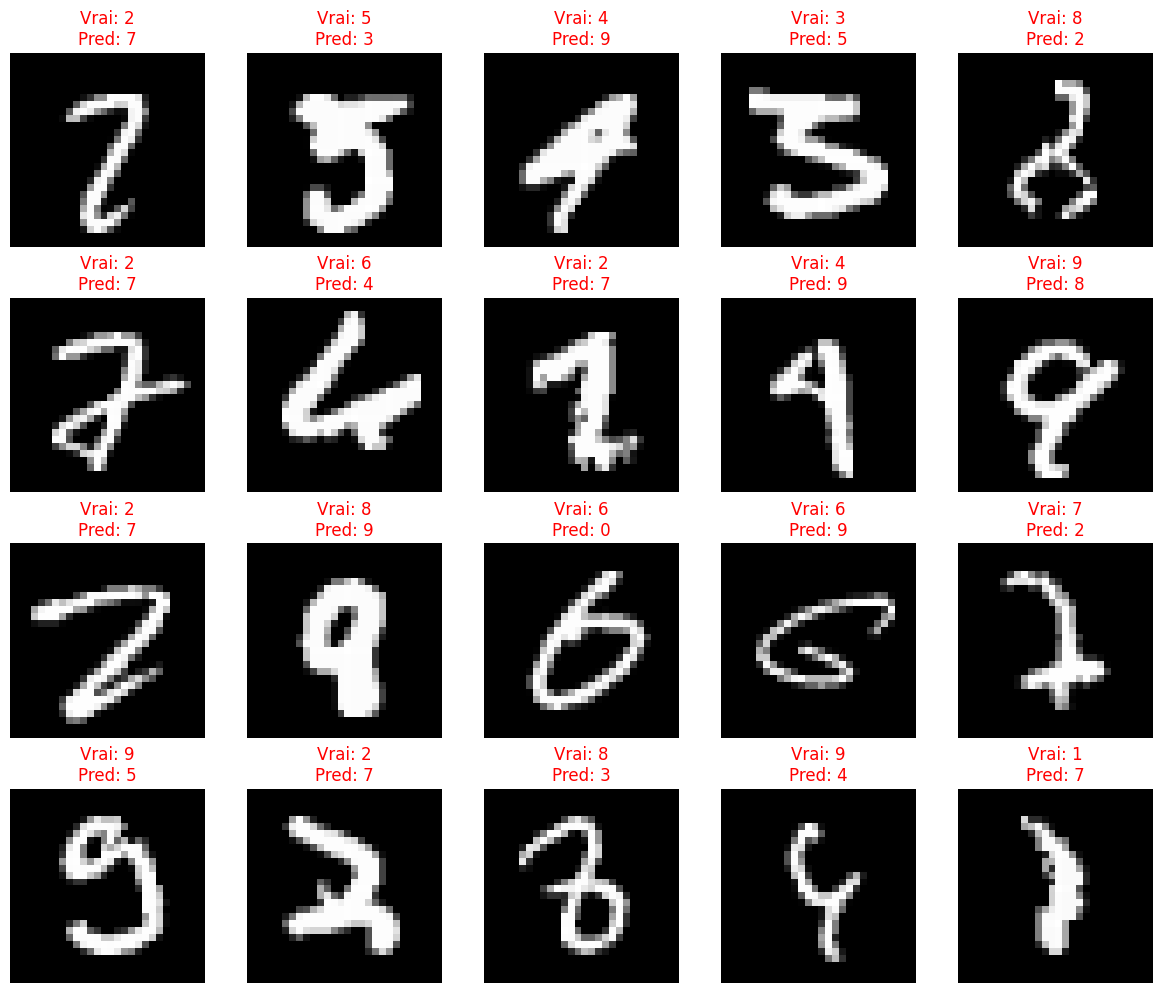

In [449]:
def show_mistakes(model, loader, device, max_images=20):
    """Je cherche des images mal classées pour comprendre les erreurs."""
    model.eval()
    mistakes = []

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            predictions = outputs.argmax(dim=1).cpu()

            # Je garde seulement les cas où la prédiction est différente
            # de la vraie étiquette.
            for image, true_label, pred_label in zip(images, labels, predictions):
                if true_label.item() != pred_label.item():
                    mistakes.append((image, true_label.item(), pred_label.item()))
                if len(mistakes) >= max_images:
                    break
            if len(mistakes) >= max_images:
                break

    if not mistakes:
        print("Aucune erreur trouvée dans les images parcourues.")
        return

    cols = 5
    rows = int(np.ceil(len(mistakes) / cols))
    plt.figure(figsize=(12, 2.5 * rows))

    for i, (image, true_label, pred_label) in enumerate(mistakes):
        image = denormalize_mnist(image).squeeze(0).numpy()
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Vrai: {true_label}\nPred: {pred_label}", color="red")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_mistakes(model, test_loader, device, max_images=20)


## 16. Pistes pour perfectionner le modèle

Cette section sert de guide d'expérimentation.

Quelques pistes :

- augmenter `EPOCHS` si la validation continue de progresser ;
- activer `USE_AUGMENTATION` si le modèle surapprend ;
- augmenter `DROPOUT_RATE` pour forcer le modèle à généraliser davantage ;
- modifier `LEARNING_RATE` si l'apprentissage est trop lent ou instable ;
- tester `cnn_3conv` pour donner plus de capacité au modèle.

Le but est d'observer, modifier un paramètre, relancer, puis comparer les résultats.


## 17. Sauvegarde du modèle

Une fois le modèle entraîné, je sauvegarde ses poids dans `cnn_mnist.pth`.

Le fichier ne contient pas tout le code du modèle : il contient les paramètres appris pendant l'entraînement.

Cela permet de réutiliser le modèle plus tard sans refaire toute la phase d'entraînement.


In [450]:
# Je sauvegarde uniquement les poids appris par le modèle.
# Cela permet de recharger le modèle plus tard sans refaire tout l'entraînement.
torch.save(model.state_dict(), "cnn_mnist.pth")
print("Modèle sauvegardé dans cnn_mnist.pth")


Modèle sauvegardé dans cnn_mnist.pth


## 18. Test des images personnelles dans `df/`

Cette section teste des images personnelles rangées dans `df/test`.

Une photo réelle ne ressemble pas directement à MNIST. MNIST contient des chiffres blancs centrés sur fond noir, au format `28 x 28`. Une photo personnelle peut contenir un fond clair, une mauvaise orientation, une marge, du bruit ou une taille différente.

Je dois donc appliquer un prétraitement spécifique :

- passage en niveaux de gris ;
- correction éventuelle de l'orientation EXIF ;
- amélioration du contraste ;
- suppression d'une zone haute parasite ;
- détection des pixels foncés correspondant à l'encre ;
- recadrage autour du chiffre ;
- conversion au style MNIST : fond noir, chiffre blanc ;
- centrage dans une image carrée ;
- redimensionnement en `28 x 28` ;
- normalisation avec les statistiques MNIST.

Cette partie montre une difficulté importante : un modèle entraîné sur MNIST fonctionne très bien sur MNIST, mais les images réelles doivent souvent être adaptées pour ressembler au format d'entraînement.


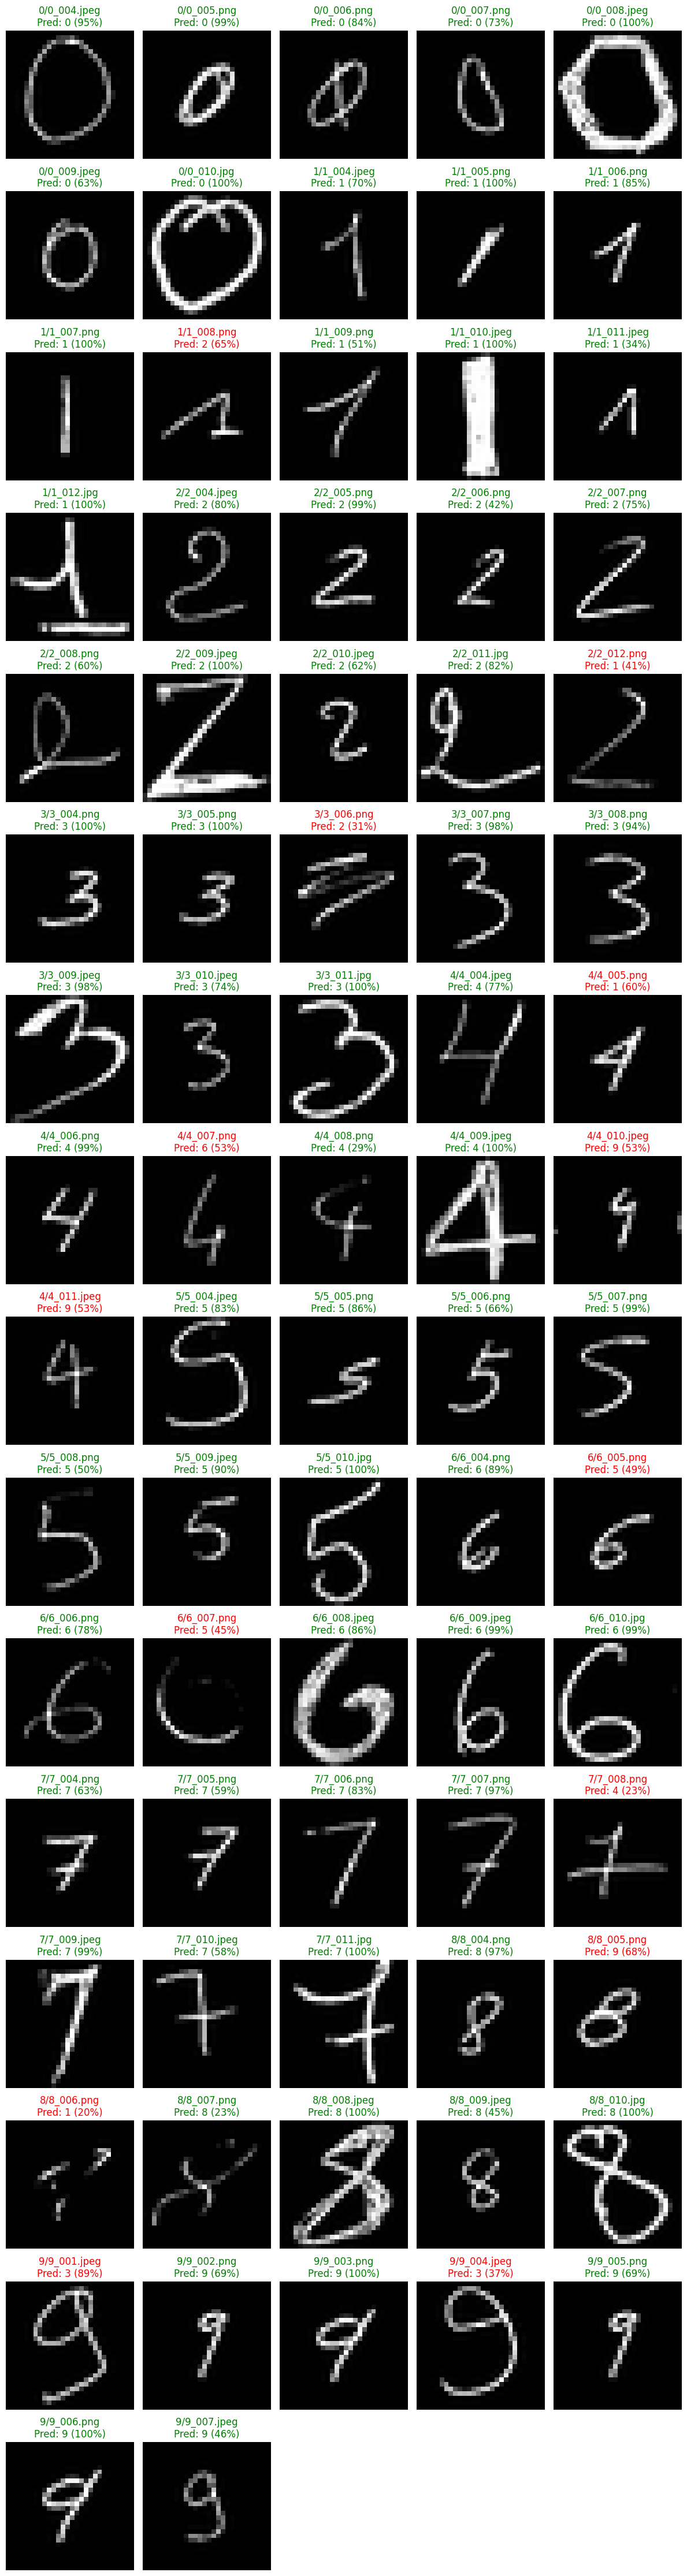

Résultats :
0/0_004.jpeg     | attendu: 0 | prédit: 0 | confiance: 94.72% | ok: True
0/0_005.png      | attendu: 0 | prédit: 0 | confiance: 99.42% | ok: True
0/0_006.png      | attendu: 0 | prédit: 0 | confiance: 84.39% | ok: True
0/0_007.png      | attendu: 0 | prédit: 0 | confiance: 72.86% | ok: True
0/0_008.jpeg     | attendu: 0 | prédit: 0 | confiance: 100.00% | ok: True
0/0_009.jpeg     | attendu: 0 | prédit: 0 | confiance: 63.01% | ok: True
0/0_010.jpg      | attendu: 0 | prédit: 0 | confiance: 100.00% | ok: True
1/1_004.jpeg     | attendu: 1 | prédit: 1 | confiance: 70.30% | ok: True
1/1_005.png      | attendu: 1 | prédit: 1 | confiance: 99.99% | ok: True
1/1_006.png      | attendu: 1 | prédit: 1 | confiance: 84.68% | ok: True
1/1_007.png      | attendu: 1 | prédit: 1 | confiance: 99.55% | ok: True
1/1_008.png      | attendu: 1 | prédit: 2 | confiance: 64.85% | ok: False
1/1_009.png      | attendu: 1 | prédit: 1 | confiance: 50.54% | ok: True
1/1_010.jpeg     | attendu: 1 | préd

In [454]:
from pathlib import Path
from PIL import Image, ImageOps

# False = je ne redresse pas automatiquement les photos selon l'orientation EXIF.
# Si certaines photos apparaissent de côté, je passe cette variable à True.
APPLY_EXIF_ORIENTATION = False

# True  = j'affiche l'image transformée comme elle est envoyée au modèle MNIST.
# False = j'affiche l'image brute du fichier, sans recadrage ni mise au format MNIST.
DISPLAY_PREPROCESSED_TEST_IMAGES = True


def preprocess_real_digit_for_mnist(image_path):
    """Je transforme une photo personnelle pour qu'elle ressemble à une image MNIST."""
    original = Image.open(image_path)
    if APPLY_EXIF_ORIENTATION:
        original = ImageOps.exif_transpose(original)

    # Je passe en niveaux de gris, puis j'améliore le contraste.
    original = original.convert("L")
    original = ImageOps.autocontrast(original)
    arr = np.array(original)
    h, w = arr.shape

    # J'ignore le haut de l'image pour éviter de détecter une interface
    # de capture ou une zone parasite au lieu du chiffre.
    working = arr.copy()
    working[: int(0.18 * h), :] = 255

    # Le chiffre est écrit en sombre : je localise les pixels les plus foncés.
    ink_mask = working <= 95
    ys, xs = np.where(ink_mask)
    if len(xs) == 0 or len(ys) == 0:
        raise ValueError(f"Aucun chiffre détecté dans {image_path}")

    # Je recadre autour de l'encre, avec une marge pour ne pas couper le chiffre.
    pad = 35
    x1 = max(xs.min() - pad, 0)
    y1 = max(ys.min() - pad, 0)
    x2 = min(xs.max() + pad, w - 1)
    y2 = min(ys.max() + pad, h - 1)

    crop = original.crop((x1, y1, x2 + 1, y2 + 1))
    crop_arr = np.array(crop)

    # Style MNIST : fond noir, trait blanc.
    binary_digit = np.zeros_like(crop_arr)
    binary_digit[crop_arr <= 105] = 255

    # Je centre le chiffre dans une image carrée avant de le redimensionner en 28 x 28.
    digit_img = Image.fromarray(binary_digit)
    cw, ch = digit_img.size
    side = max(cw, ch)
    square = Image.new("L", (side, side), 0)
    square.paste(digit_img, ((side - cw) // 2, (side - ch) // 2))
    square = square.resize((28, 28), Image.Resampling.LANCZOS)

    # Je transforme l'image finale en tenseur normalisé, exactement comme MNIST.
    tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])(square).unsqueeze(0)

    return tensor, square


def list_digit_images(folder="df/test", extensions=(".jpeg", ".jpg", ".png")):
    """Je liste les images rangées dans df/test/0, df/test/1, ..., df/test/9."""
    folder = Path(folder)
    image_paths = [
        path
        for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in extensions and path.parent.name.isdigit()
    ]

    return sorted(
        image_paths,
        key=lambda path: (int(path.parent.name), path.name),
    )


def predict_df_images(model, device, folder="df/test"):
    """Je prédis les chiffres des images personnelles et j'affiche les résultats."""
    image_paths = list_digit_images(folder)
    if not image_paths:
        raise FileNotFoundError(f"Aucune image .jpeg/.jpg/.png trouvée dans les sous-dossiers de {folder}")

    model.eval()
    results = []

    cols = 5
    rows = int(np.ceil(len(image_paths) / cols))
    plt.figure(figsize=(12, 2.8 * rows))
    for i, image_path in enumerate(image_paths):
        tensor, preview = preprocess_real_digit_for_mnist(image_path)
        tensor = tensor.to(device)

        with torch.no_grad():
            # softmax transforme les 10 scores du modèle en probabilités.
            probs = torch.softmax(model(tensor), dim=1).squeeze(0).cpu()
            prediction = int(probs.argmax().item())
            confidence = float(probs[prediction].item())

        # La vraie classe vient du dossier parent : df/test/9/9_001.jpeg -> attendu = 9.
        expected = int(image_path.parent.name)
        is_correct = expected == prediction if expected is not None else None
        relative_name = str(image_path.relative_to(Path(folder)))
        results.append((relative_name, expected, prediction, confidence, is_correct))

        title_color = "green" if is_correct else "red"
        plt.subplot(rows, cols, i + 1)
        if DISPLAY_PREPROCESSED_TEST_IMAGES:
            display_image = preview
            cmap = "gray"
        else:
            display_image = Image.open(image_path)
            if APPLY_EXIF_ORIENTATION:
                display_image = ImageOps.exif_transpose(display_image)
            cmap = None

        plt.imshow(display_image, cmap=cmap)
        plt.title(f"{relative_name}\nPred: {prediction} ({confidence:.0%})", color=title_color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    correct = sum(1 for *_, is_correct in results if is_correct)
    print("Résultats :")
    for filename, expected, prediction, confidence, is_correct in results:
        print(f"{filename:16s} | attendu: {expected} | prédit: {prediction} | confiance: {confidence:.2%} | ok: {is_correct}")

    print(f"\nAccuracy sur les images de {folder} : {correct}/{len(results)} = {correct / len(results):.2%}")
    return results


# Je lance le test sur les images personnelles rangées dans df/test.
df_results = predict_df_images(model, device, folder="df/test")


## 19. Diagnostic orientation d'une image

Certaines photos prises avec un smartphone peuvent apparaître tournées selon le logiciel utilisé. Cela vient souvent de l'orientation EXIF, une métadonnée stockée dans le fichier image.

Cette cellule affiche trois versions d'une même image :

- le fichier brut ;
- l'image avec l'orientation EXIF appliquée ;
- l'image finale prétraitée au format MNIST.

Cela permet de savoir si une mauvaise prédiction vient du modèle ou simplement d'une image mal orientée avant le prétraitement.


Image : df/test/0/0_008.jpeg
Taille brute : (3024, 4032)
Orientation EXIF : None


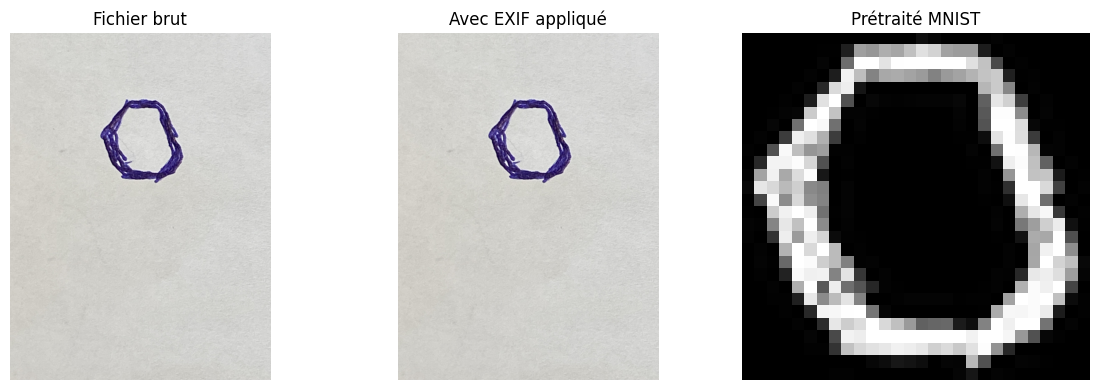

In [452]:
def debug_image_orientation(image_path):
    """J'affiche trois versions d'une image pour diagnostiquer son orientation."""
    image_path = Path(image_path)
    raw = Image.open(image_path)
    exif_orientation = raw.getexif().get(274)
    exif_corrected = ImageOps.exif_transpose(raw)
    _, mnist_preview = preprocess_real_digit_for_mnist(image_path)

    print(f"Image : {image_path}")
    print(f"Taille brute : {raw.size}")
    print(f"Orientation EXIF : {exif_orientation}")

    plt.figure(figsize=(12, 4))

    # Version 1 : ce que contient réellement le fichier image.
    plt.subplot(1, 3, 1)
    plt.imshow(raw)
    plt.title("Fichier brut")
    plt.axis("off")

    # Version 2 : ce que donne l'image si j'applique l'orientation EXIF.
    plt.subplot(1, 3, 2)
    plt.imshow(exif_corrected)
    plt.title("Avec EXIF appliqué")
    plt.axis("off")

    # Version 3 : ce que le modèle reçoit après le prétraitement MNIST.
    plt.subplot(1, 3, 3)
    plt.imshow(mnist_preview, cmap="gray")
    plt.title("Prétraité MNIST")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# Exemple : je change le chemin si je veux inspecter une image précise.
debug_image_orientation("df/test/0/0_008.jpeg")


Cette vérification m'a été utile pendant le projet : certaines photos prises sur smartphone étaient affichées de côté, et le modèle ne les reconnaissait pas correctement.

En affichant les différentes versions de l'image, j'ai pu comprendre que le problème ne venait pas forcément du CNN, mais parfois de l'orientation EXIF ou du prétraitement appliqué avant la prédiction. Ici j'ai détruit la donnée qui provenait du capteur qui indiquait l'inclinaisaon au moment de la prise de vue.
